In [6]:
from torch.utils.data import Dataset, DataLoader

def load_splits(
    splits_dir: str     = SPLITS_DIR,
    tokenizer_name: str = ROBERTA_NAME,
    max_len: int        = MAX_LEN,
    batch_size: int     = BATCH_SIZE,
):
    train_df = pd.read_csv(os.path.join(splits_dir, "train.csv"))
    val_df   = pd.read_csv(os.path.join(splits_dir, "val.csv"))
    test_df  = pd.read_csv(os.path.join(splits_dir, "test.csv"))
    map_df   = pd.read_csv(os.path.join(splits_dir, "label_mapping.csv"))

    # Проверяем маппинг
    for _, row in map_df.iterrows():
        expected = CLASS_TO_ID[row["class_name"]]
        actual   = int(row["class_id"])
        assert expected == actual, (
            f"Mapping mismatch: {row['class_name']} "
            f"expected id={expected}, got id={actual}. "
            f"Re-run prepare_and_save_splits()!"
        )

    num_labels = len(emotion_classes)
    samples_per_class = [int((train_df["label_id"] == i).sum()) for i in range(num_labels)]

    print(f"Splits loaded from: {splits_dir}/")
    print(f"  Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
    print(f"\n  Train samples per class:")
    for i, cls in enumerate(emotion_classes):
        print(f"    id={i}  {cls:<12}: {samples_per_class[i]:>5}")

    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)

    X_train, y_train = train_df["tweet_text"], train_df["label_id"]
    X_val,   y_val   = val_df["tweet_text"],   val_df["label_id"]
    X_test,  y_test  = test_df["tweet_text"],  test_df["label_id"]

    ds_train = TweetDataset(X_train, y_train, tokenizer, max_len)
    ds_val   = TweetDataset(X_val,   y_val,   tokenizer, max_len)
    ds_test  = TweetDataset(X_test,  y_test,  tokenizer, max_len)

    loaders = {
        "train": DataLoader(ds_train, batch_size=batch_size,     shuffle=True),
        "val":   DataLoader(ds_val,   batch_size=batch_size * 2, shuffle=False),
        "test":  DataLoader(ds_test,  batch_size=batch_size * 2, shuffle=False),
    }

    meta = {
        "num_labels":        num_labels,
        "samples_per_class": samples_per_class,
        "tokenizer":         tokenizer,
        "X_train": X_train, "y_train": y_train,
        "X_val":   X_val,   "y_val":   y_val,
        "X_test":  X_test,  "y_test":  y_test,
        "train_df": train_df,
        "val_df":   val_df,
        "test_df":  test_df,
    }

    return loaders, meta

class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts.reset_index(drop=True)
        self.labels    = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            add_special_tokens=True,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
            return_tensors="pt",
        )
        return {
            "input_ids":      encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels":         torch.tensor(int(self.labels[idx]), dtype=torch.long),
        }

Device: cuda
Splits loaded from: splits/
  Train: 7134 | Val: 1260 | Test: 1482

  Train samples per class:
    id=0  neutral     :  2313
    id=1  happiness   :  1745
    id=2  anger       :  1129
    id=3  disgust     :   368
    id=4  sadness     :  1057
    id=5  surprise    :   368
    id=6  fear        :   154
Train: 7134 | Val: 1260 | Test: 1482

  1. CLS Token (baseline)


Loading weights: 100%|████████████████████████████████████████████████████████| 197/197 [00:00<00:00, 5615.70it/s]
RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
                                                                                                                 

  Ep 1/10  trL=1.6157 trF1=0.2738  vaL=1.0070 vaF1=0.4317  ✓


  Ep 2/10  trL=1.1657 trF1=0.5025  vaL=0.9242 vaF1=0.5535  ✓


  Ep 3/10  trL=0.9643 trF1=0.6561  vaL=0.8813 vaF1=0.6113  ✓


...

  Ep 7/10  trL=0.6061 trF1=0.9370  vaL=0.9657 vaF1=0.6052  ✓


  Ep 8/10  trL=0.5822 trF1=0.9556  vaL=0.9925 vaF1=0.6036  ⏳ 1/3


  Ep 9/10  trL=0.5571 trF1=0.9718  vaL=1.0233 vaF1=0.6093  ✓


  Ep 10/10  trL=0.5506 trF1=0.9741  vaL=1.0272 vaF1=0.6066  ⏳ 1/3



  Test loss=0.9591  Macro F1=0.6376
              precision    recall  f1-score   support

     neutral     0.7743    0.7630    0.7686       481
   happiness     0.7416    0.7928    0.7664       362
       anger     0.7321    0.7009    0.7162       234
     disgust     0.5333    0.4156    0.4672        77
     sadness     0.7189    0.7091    0.7140       220
    surprise     0.5054    0.6184    0.5562        76
        fear     0.5185    0.4375    0.4746        32

    accuracy                         0.7200      1482
   macro avg     0.6463    0.6339    0.6376      1482
weighted avg     0.7196    0.7200    0.7188      1482



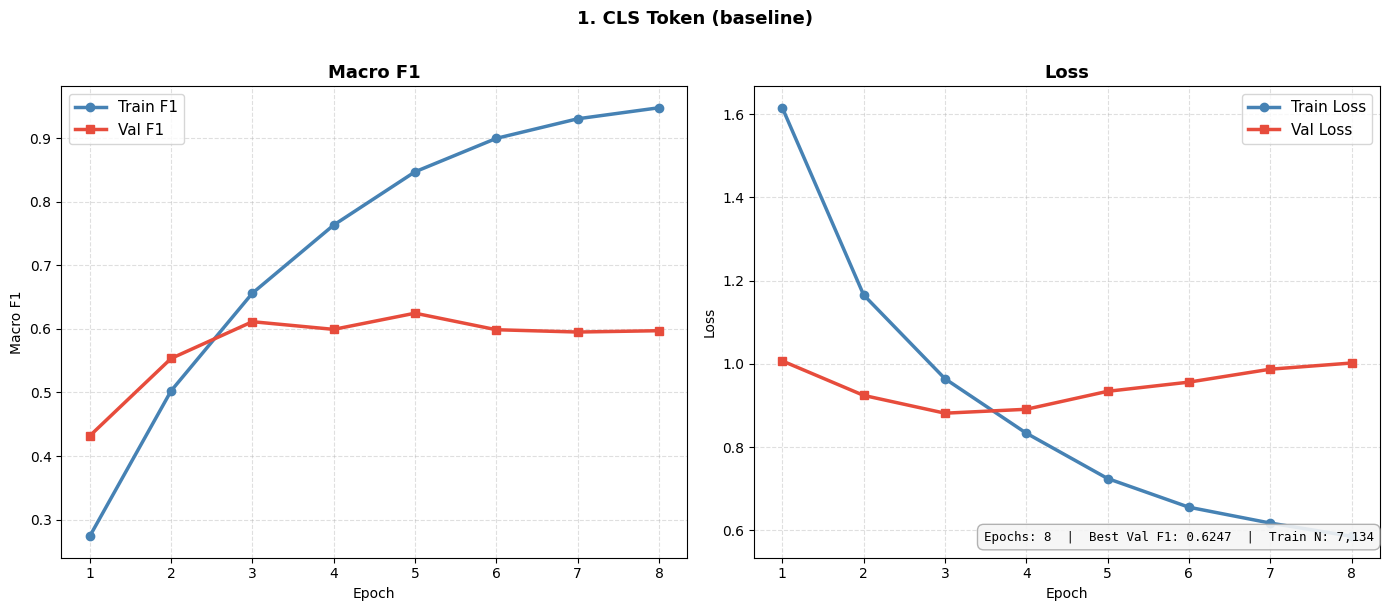

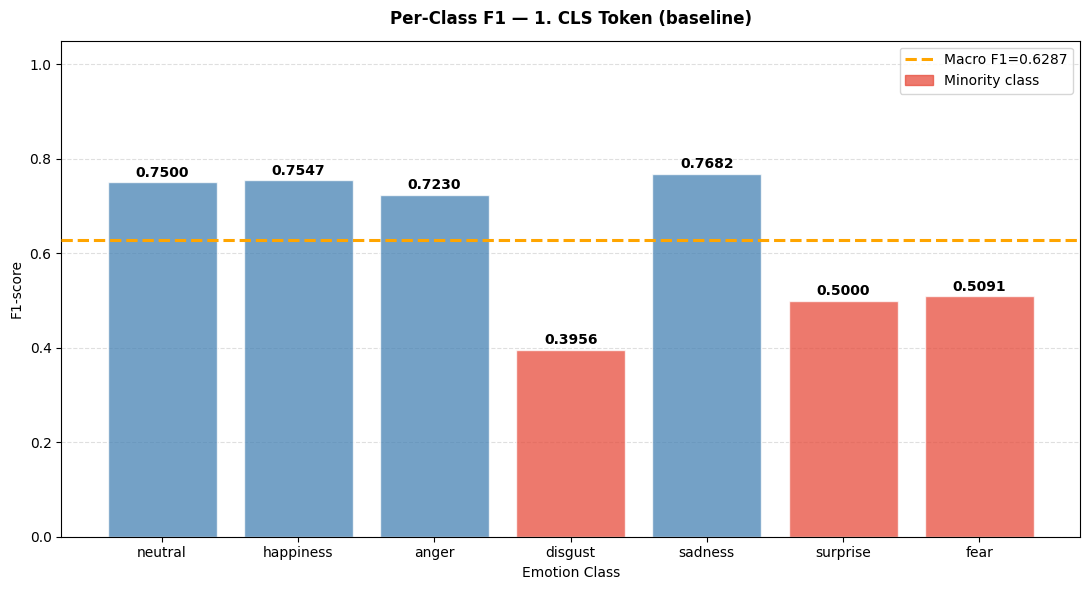

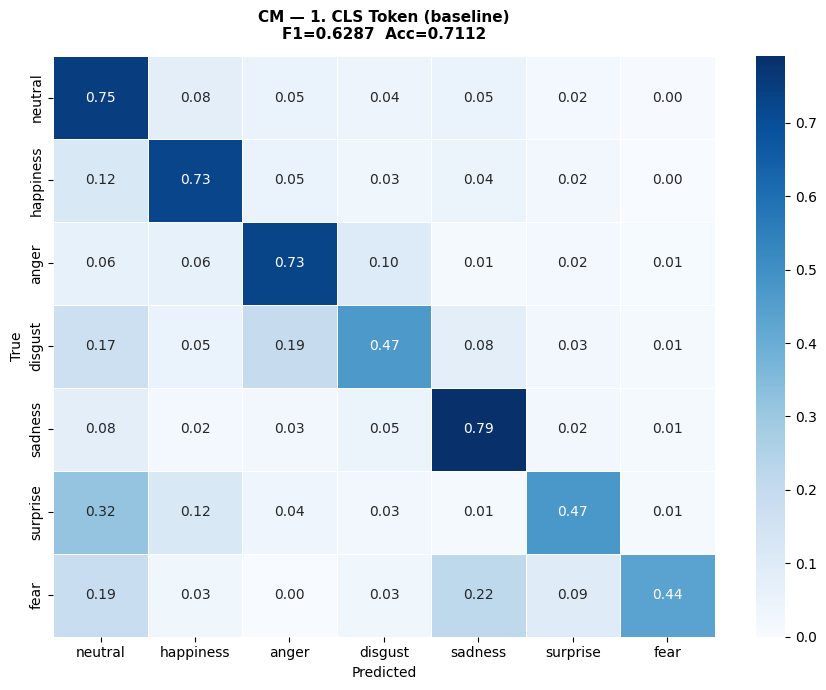

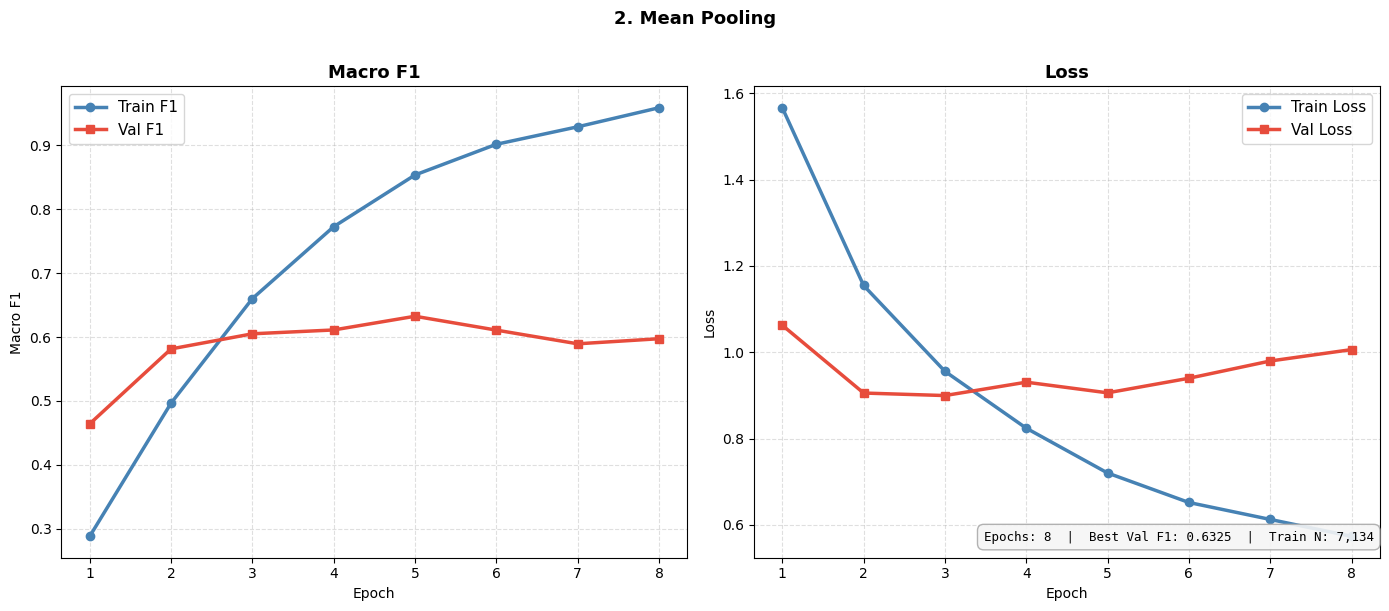

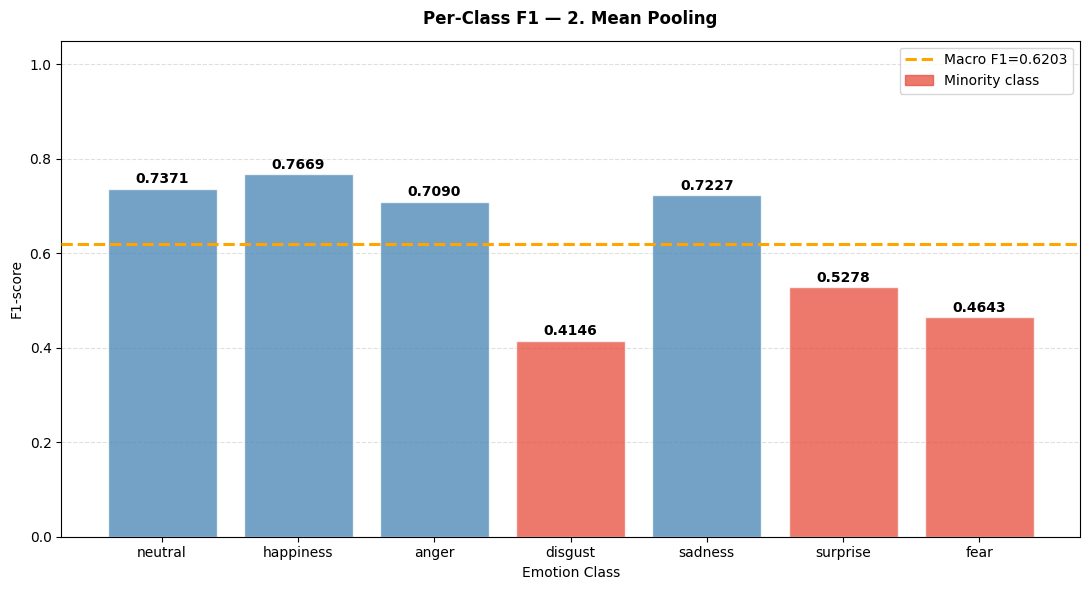

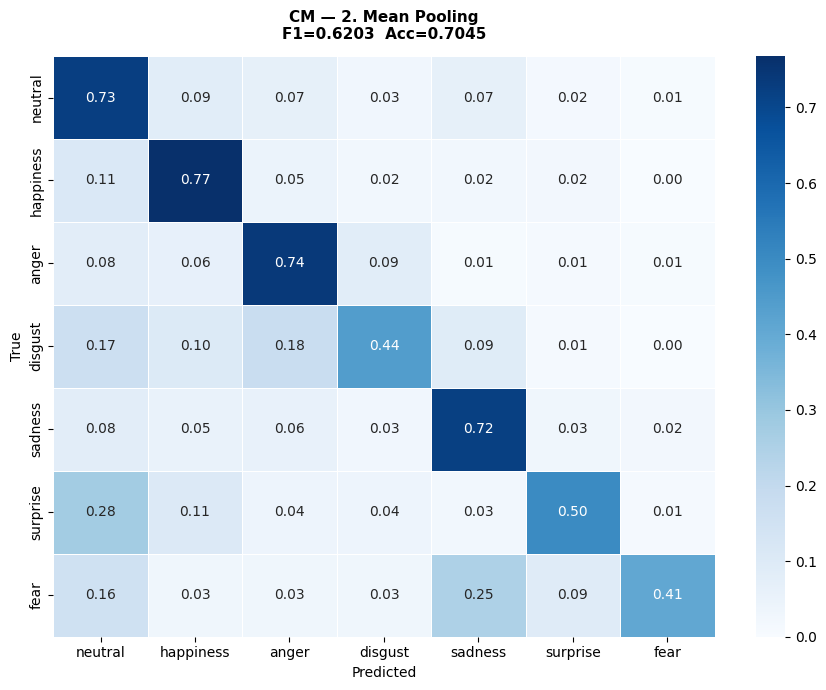

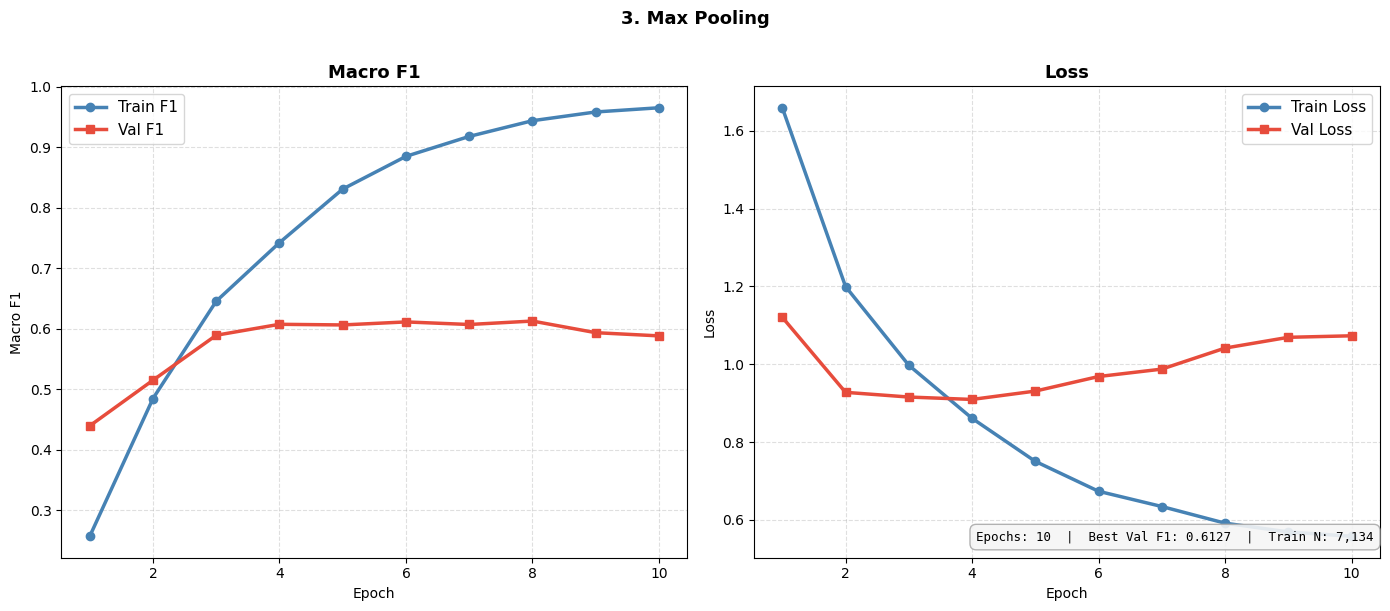

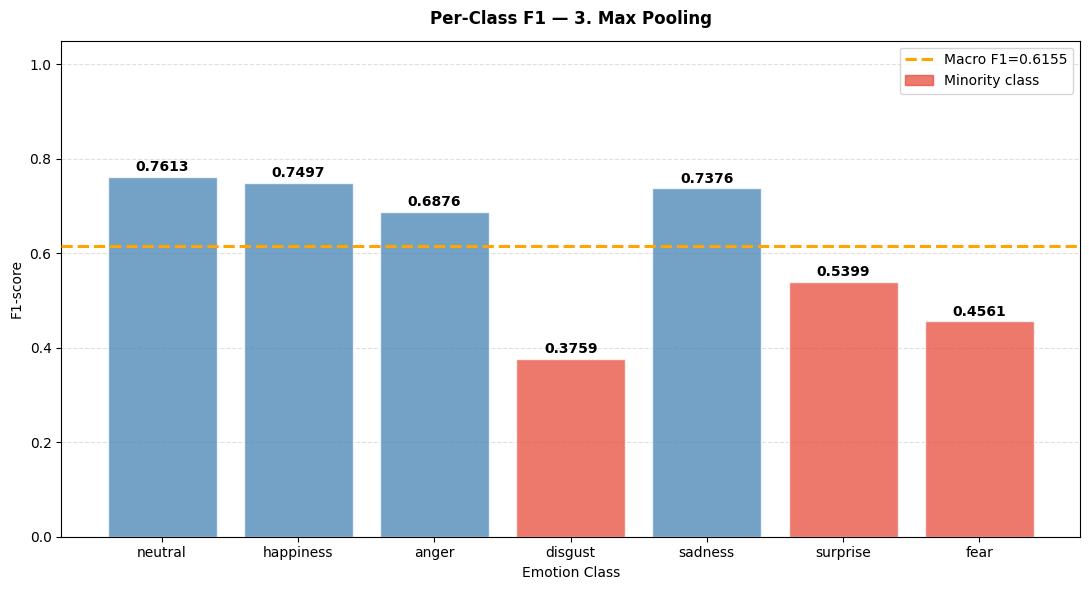

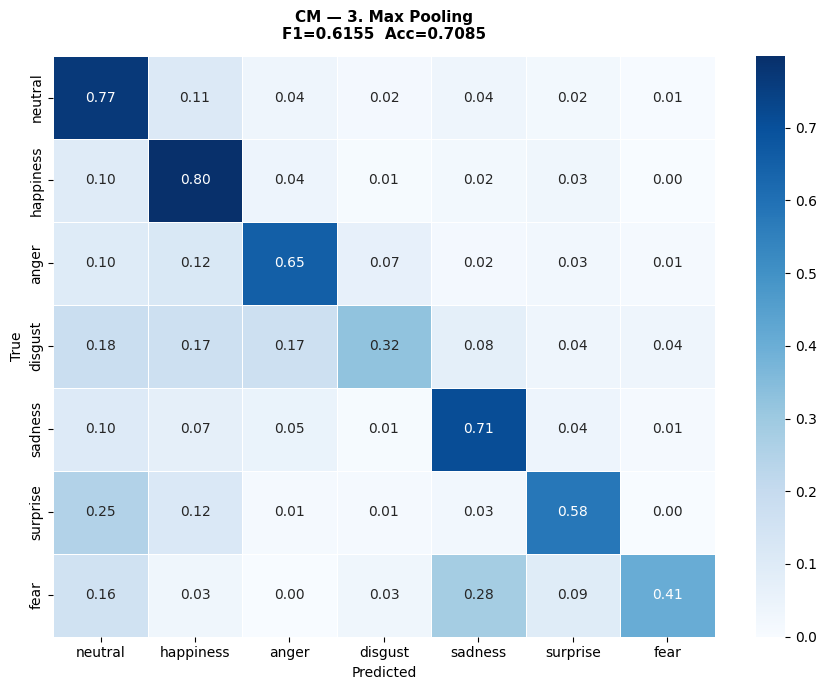

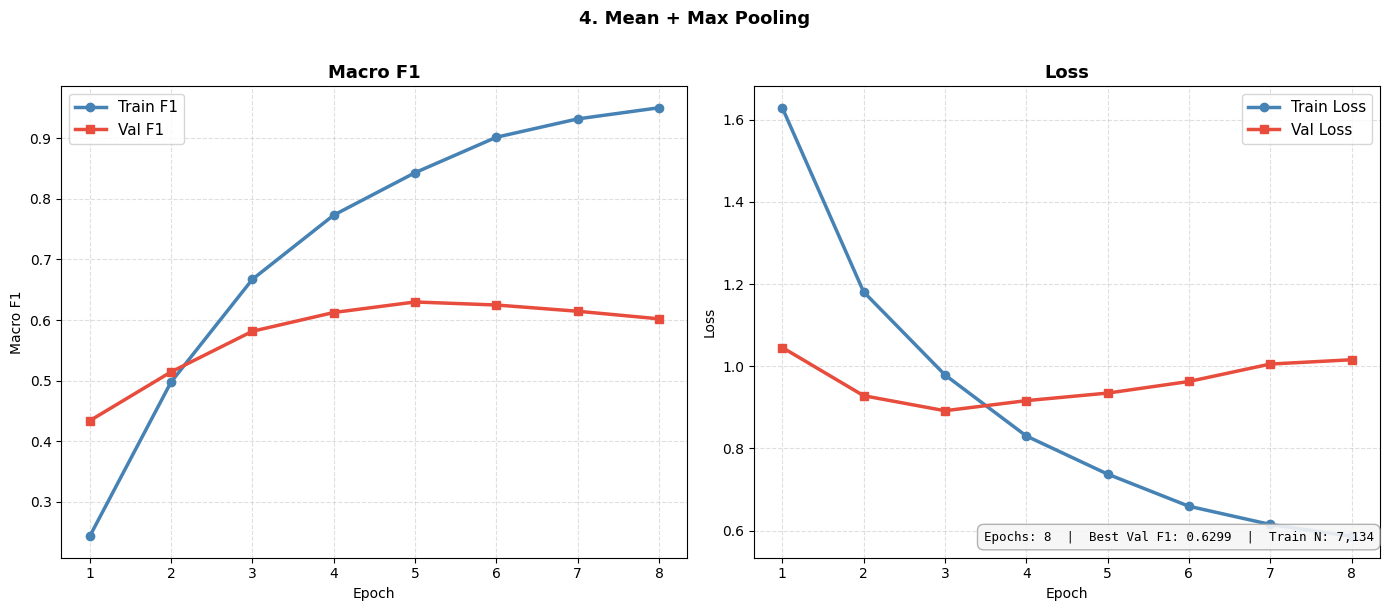

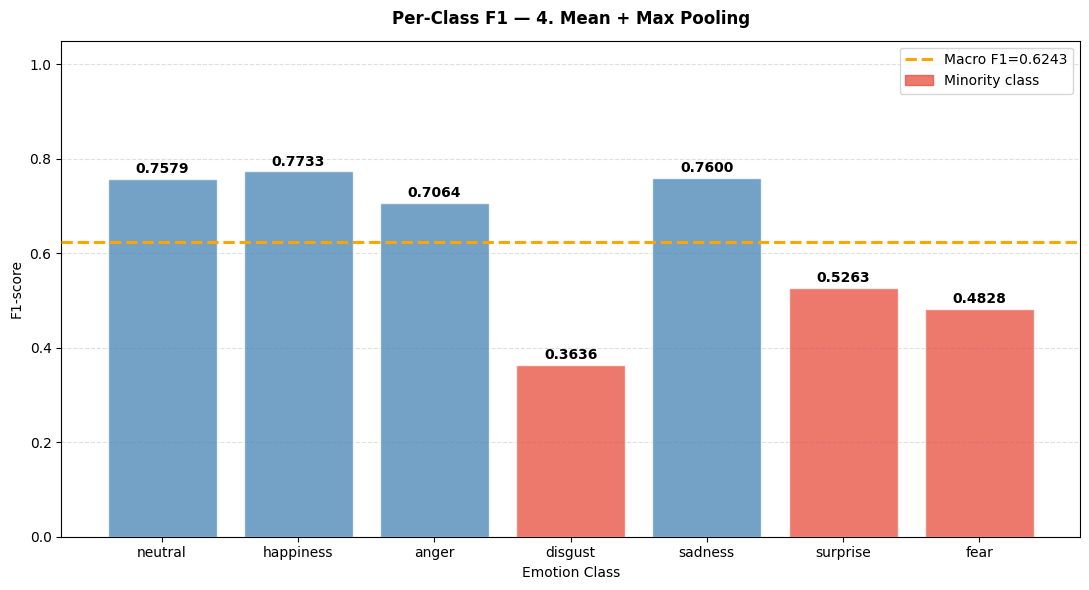

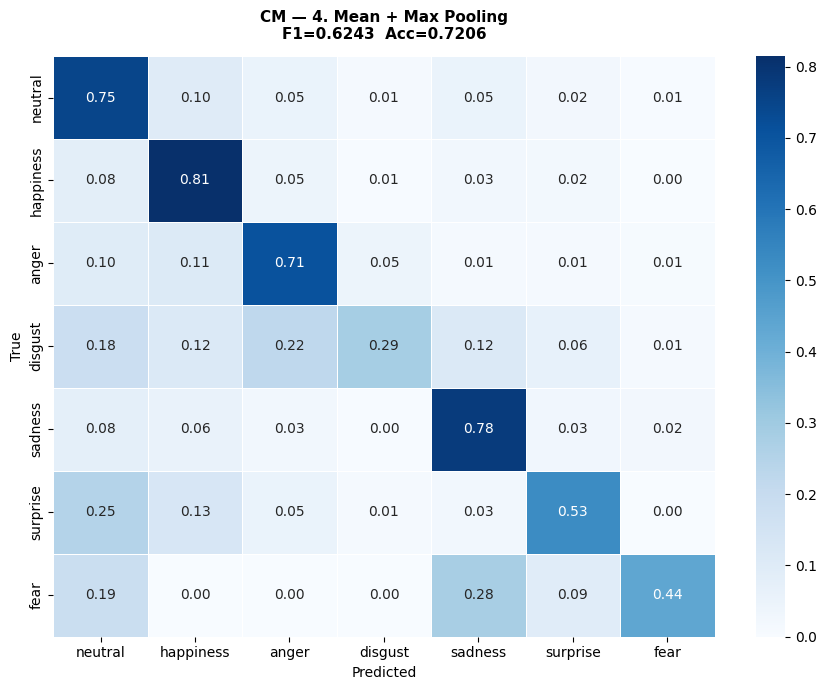

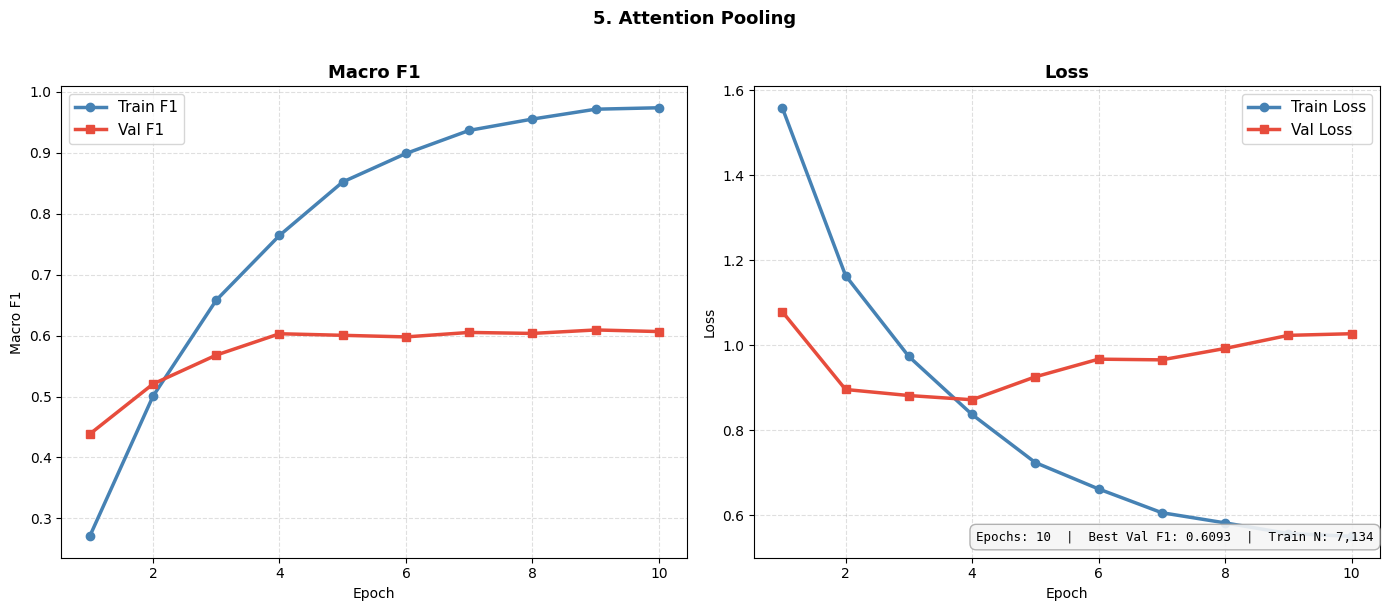

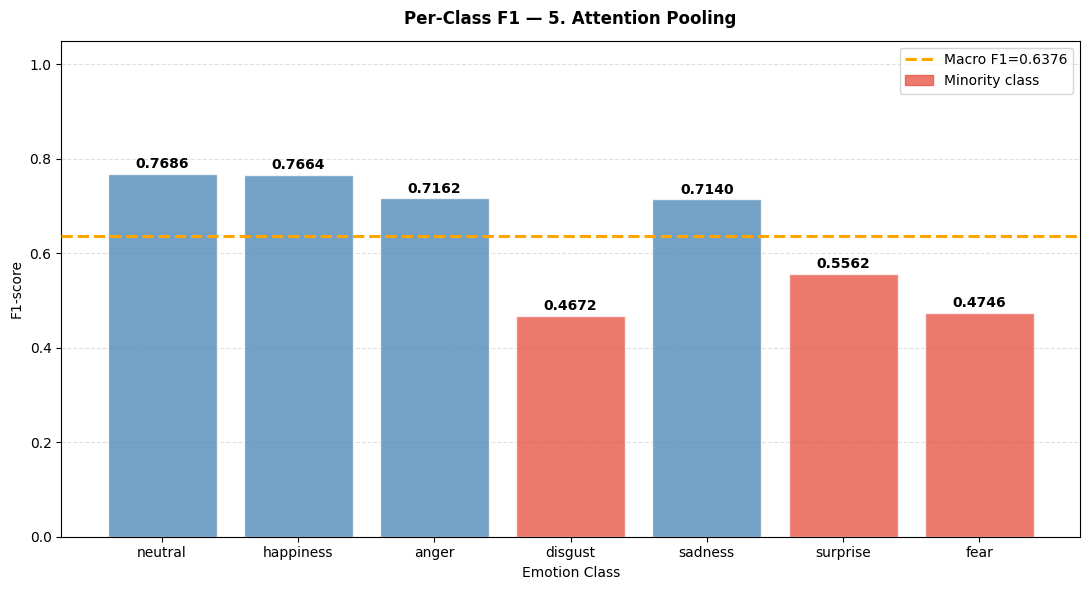

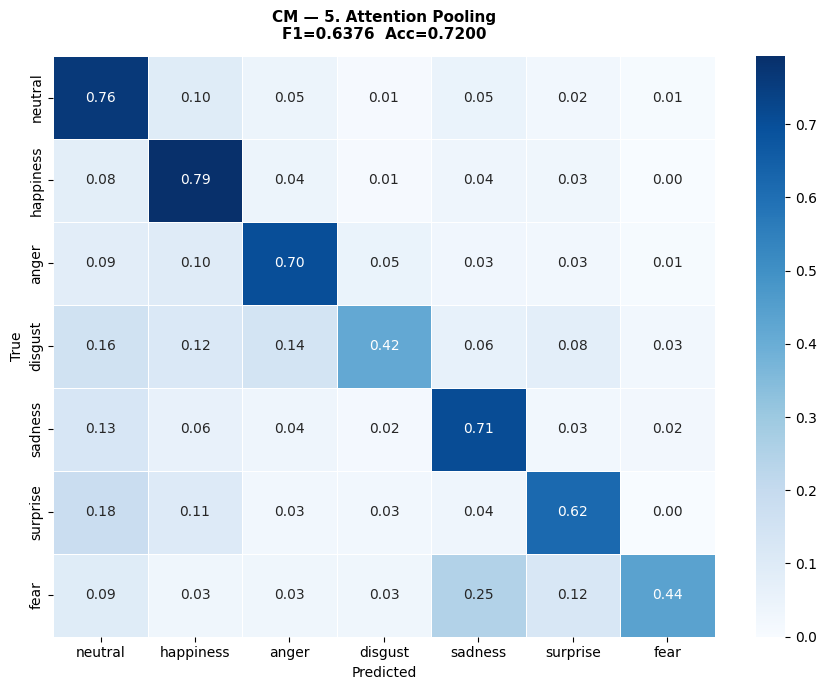

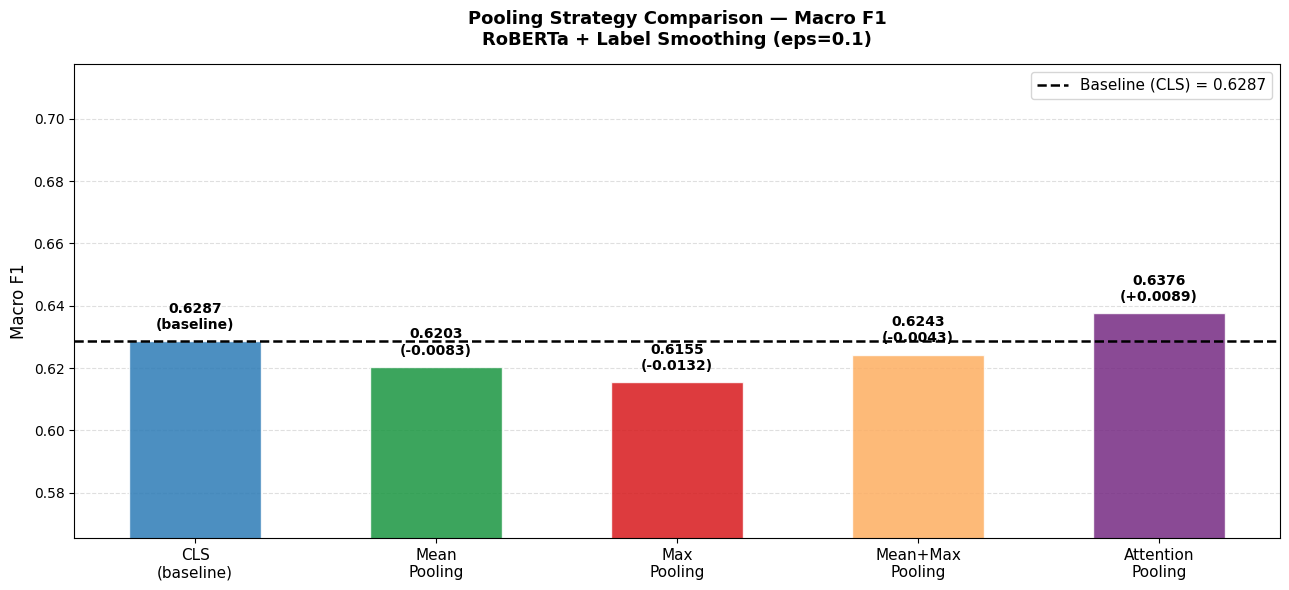

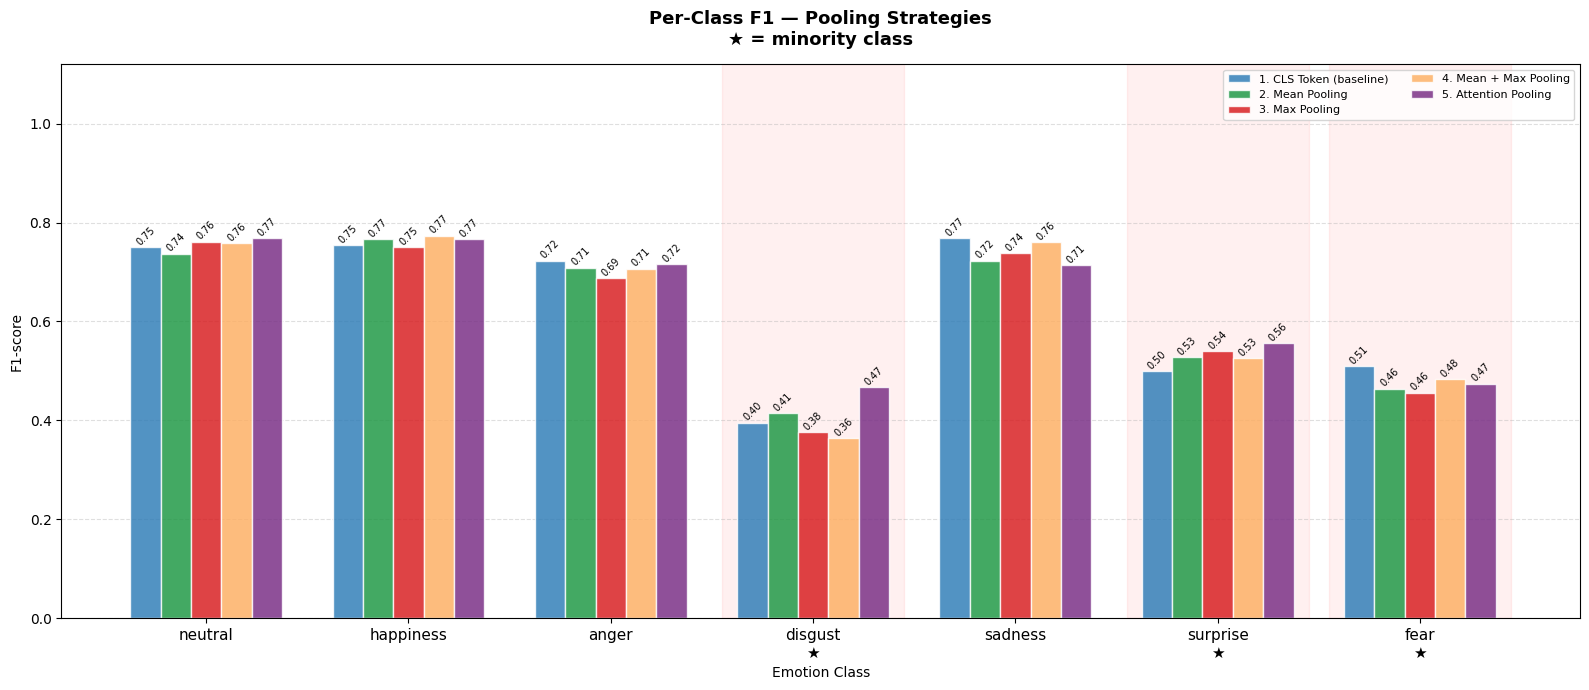

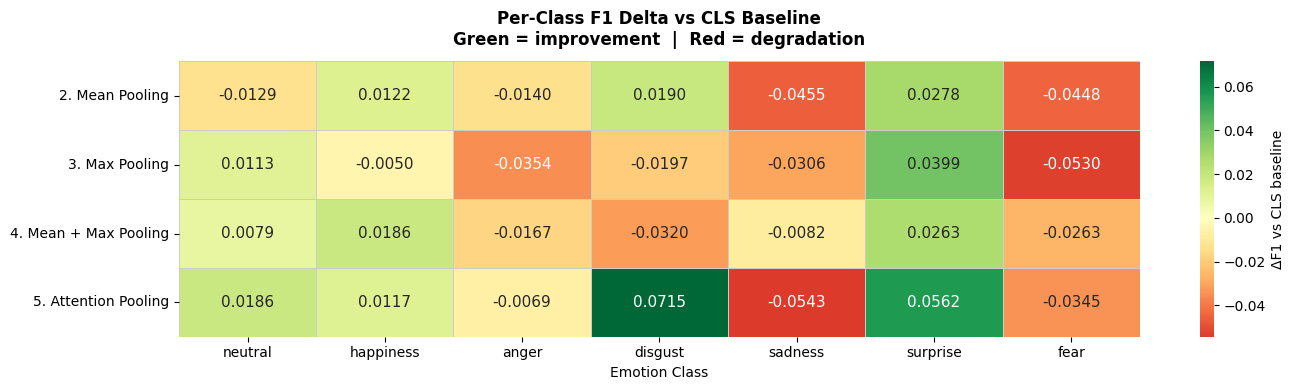


  POOLING STRATEGY COMPARISON — RoBERTa + Label Smoothing

                         Epochs  Accuracy  Macro P  Macro R  Macro F1  Weighted F1  Val F1 Δ Macro F1
Method                                                                                               
1. CLS Token (baseline)       8    0.7112   0.6400   0.6251    0.6287       0.7132  0.6247    +0.0000
2. Mean Pooling               8    0.7045   0.6300   0.6148    0.6203       0.7044  0.6325    -0.0083
3. Max Pooling               10    0.7085   0.6323   0.6058    0.6155       0.7053  0.6127    -0.0132
4. Mean + Max Pooling         8    0.7206   0.6450   0.6142    0.6243       0.7155  0.6299    -0.0043
5. Attention Pooling         10    0.7200   0.6463   0.6339    0.6376       0.7188  0.6093    +0.0089

  PER-CLASS F1

                         neutral  happiness   anger  disgust  sadness  surprise    fear
Method                                                                                 
1. CLS Token (baseline)   0.7500 

In [7]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import re
import random
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from torch.utils.data import DataLoader
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy

# ============================================================
# КОНФИГУРАЦИЯ
# ============================================================

ROBERTA_NAME = "roberta-base"
MAX_LEN      = 128
BATCH_SIZE   = 32
EPOCHS       = 10
LEARNING_RATE = 2e-5
WARMUP_RATIO  = 0.1
WEIGHT_DECAY  = 0.01
PATIENCE      = 3
SEED          = 42

emotion_classes  = ["neutral", "happiness", "anger", "disgust", "sadness", "surprise", "fear"]
CLASS_TO_ID      = {cls: i for i, cls in enumerate(emotion_classes)}
MINORITY_CLASSES = ["fear", "disgust", "surprise"]

SPLITS_DIR = "splits"
OUTPUT_DIR = "pooling_experiments"
os.makedirs(OUTPUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

def set_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

# ============================================================
# ЛОСС
# ============================================================

class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing

    def forward(self, logits, targets):
        n_classes = logits.size(-1)
        log_prob  = F.log_softmax(logits, dim=-1)
        with torch.no_grad():
            dist = torch.full_like(log_prob, self.smoothing / (n_classes - 1))
            dist.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        return -(dist * log_prob).sum(dim=-1).mean()

# ============================================================
# МОДЕЛИ — 5 ВАРИАНТОВ ПУЛИНГА
# ============================================================

class RobertaCLS(nn.Module):
    """1. CLS токен — baseline этого этапа."""
    def __init__(self, model_name, num_labels):
        super().__init__()
        self.backbone   = AutoModel.from_pretrained(model_name)
        self.dropout    = nn.Dropout(0.3)
        self.classifier = nn.Linear(self.backbone.config.hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        out = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0]           # [B, H]
        return self.classifier(self.dropout(cls))


class RobertaMeanPooling(nn.Module):
    """2. Mean Pooling — среднее по всем токенам (с учётом маски)."""
    def __init__(self, model_name, num_labels):
        super().__init__()
        self.backbone   = AutoModel.from_pretrained(model_name)
        self.dropout    = nn.Dropout(0.3)
        self.classifier = nn.Linear(self.backbone.config.hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        out  = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        seq  = out.last_hidden_state                # [B, T, H]
        mask = attention_mask.unsqueeze(-1).float() # [B, T, 1]
        mean = (seq * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)  # [B, H]
        return self.classifier(self.dropout(mean))


class RobertaMaxPooling(nn.Module):
    """3. Max Pooling — максимум по всем токенам."""
    def __init__(self, model_name, num_labels):
        super().__init__()
        self.backbone   = AutoModel.from_pretrained(model_name)
        self.dropout    = nn.Dropout(0.3)
        self.classifier = nn.Linear(self.backbone.config.hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        out  = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        seq  = out.last_hidden_state                          # [B, T, H]
        # Паддинг-токены → -inf чтобы не влияли на max
        mask = attention_mask.unsqueeze(-1).bool()
        seq  = seq.masked_fill(~mask, float('-inf'))
        mx   = seq.max(dim=1).values                          # [B, H]
        return self.classifier(self.dropout(mx))


class RobertaMeanMaxPooling(nn.Module):
    """4. Mean + Max — конкатенация обоих."""
    def __init__(self, model_name, num_labels):
        super().__init__()
        self.backbone   = AutoModel.from_pretrained(model_name)
        self.dropout    = nn.Dropout(0.3)
        hidden = self.backbone.config.hidden_size
        self.classifier = nn.Linear(hidden * 2, num_labels)  # *2 из-за concat

    def forward(self, input_ids, attention_mask):
        out  = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        seq  = out.last_hidden_state                          # [B, T, H]
        mask = attention_mask.unsqueeze(-1)

        # Mean
        mean = (seq * mask.float()).sum(1) / mask.float().sum(1).clamp(min=1e-9)

        # Max
        seq_masked = seq.masked_fill(~mask.bool(), float('-inf'))
        mx = seq_masked.max(dim=1).values

        cat = torch.cat([mean, mx], dim=-1)                   # [B, 2H]
        return self.classifier(self.dropout(cat))


class RobertaAttentionPooling(nn.Module):
    """
    5. Attention Pooling — обучаемый вектор внимания поверх hidden states.
    Считает скалярный score для каждого токена → softmax → взвешенная сумма.
    """
    def __init__(self, model_name, num_labels):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        hidden = self.backbone.config.hidden_size

        # Обучаемый attention слой: hidden → scalar
        self.attention = nn.Sequential(
            nn.Linear(hidden, 256),
            nn.Tanh(),
            nn.Linear(256, 1),
        )
        self.dropout    = nn.Dropout(0.3)
        self.classifier = nn.Linear(hidden, num_labels)

    def forward(self, input_ids, attention_mask):
        out = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        seq = out.last_hidden_state                           # [B, T, H]

        # Scores → маскируем паддинг → softmax
        scores = self.attention(seq)                          # [B, T, 1]
        scores = scores.masked_fill(
            attention_mask.unsqueeze(-1) == 0, float('-inf')
        )
        weights = torch.softmax(scores, dim=1)                # [B, T, 1]

        # Взвешенная сумма
        pooled = (seq * weights).sum(dim=1)                   # [B, H]
        return self.classifier(self.dropout(pooled))

# ============================================================
# TRAIN / EVAL
# ============================================================

def train_epoch(model, loader, optimizer, scheduler, criterion):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    for batch in tqdm(loader, desc="  train", leave=False):
        ids  = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        labs = batch["labels"].to(device)
        optimizer.zero_grad()
        logits = model(ids, mask)
        loss   = criterion(logits, labs)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labs.cpu().numpy())
    return total_loss / len(loader), f1_score(all_labels, all_preds, average="macro")


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    ce = nn.CrossEntropyLoss()
    for batch in tqdm(loader, desc="  eval", leave=False):
        ids  = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        labs = batch["labels"].to(device)
        logits = model(ids, mask)
        total_loss += ce(logits, labs).item()
        probs = torch.softmax(logits, 1).cpu().numpy()
        all_preds.extend(probs.argmax(1))
        all_labels.extend(labs.cpu().numpy())
    return (total_loss / len(loader),
            f1_score(all_labels, all_preds, average="macro"),
            np.array(all_preds), np.array(all_labels))

# ============================================================
# УНИВЕРСАЛЬНЫЙ ЭКСПЕРИМЕНТ
# ============================================================

def run_experiment(model_class, display_name,
                   train_df, val_df, test_df, tokenizer):
    print(f"\n{'='*60}")
    print(f"  {display_name}")
    print(f"{'='*60}")

    set_seed(SEED)
    num_labels = len(emotion_classes)

    X_train, y_train = train_df["tweet_text"], train_df["label_id"]
    X_val,   y_val   = val_df["tweet_text"],   val_df["label_id"]
    X_test,  y_test  = test_df["tweet_text"],  test_df["label_id"]

    criterion = LabelSmoothingCrossEntropy(smoothing=0.1)

    tr_loader = DataLoader(TweetDataset(X_train, y_train, tokenizer, MAX_LEN),
                           batch_size=BATCH_SIZE, shuffle=True)
    va_loader = DataLoader(TweetDataset(X_val,   y_val,   tokenizer, MAX_LEN),
                           batch_size=BATCH_SIZE * 2)
    te_loader = DataLoader(TweetDataset(X_test,  y_test,  tokenizer, MAX_LEN),
                           batch_size=BATCH_SIZE * 2)

    set_seed(SEED)
    model     = model_class(ROBERTA_NAME, num_labels).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    total_steps = len(tr_loader) * EPOCHS
    scheduler   = get_linear_schedule_with_warmup(
        optimizer, int(total_steps * WARMUP_RATIO), total_steps)

    best_f1, patience_cnt, best_state = 0.0, 0, None
    history = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}

    for ep in range(1, EPOCHS + 1):
        tr_loss, tr_f1 = train_epoch(model, tr_loader, optimizer, scheduler, criterion)
        va_loss, va_f1, _, _ = evaluate(model, va_loader)
        history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
        history["train_f1"].append(tr_f1);     history["val_f1"].append(va_f1)

        print(f"  Ep {ep}/{EPOCHS}  "
              f"trL={tr_loss:.4f} trF1={tr_f1:.4f}  "
              f"vaL={va_loss:.4f} vaF1={va_f1:.4f}", end="")

        if va_f1 > best_f1:
            best_f1, patience_cnt = va_f1, 0
            best_state = deepcopy(model.state_dict())
            print("  ✓")
        else:
            patience_cnt += 1
            print(f"  ⏳ {patience_cnt}/{PATIENCE}")
        if patience_cnt >= PATIENCE:
            print(f"  Early stop at epoch {ep}"); break

    model.load_state_dict(best_state)
    te_loss, te_f1, te_preds, te_labels = evaluate(model, te_loader)

    rep     = classification_report(te_labels, te_preds,
                                    target_names=emotion_classes, digits=4, output_dict=True)
    rep_str = classification_report(te_labels, te_preds,
                                    target_names=emotion_classes, digits=4)
    print(f"\n  Test loss={te_loss:.4f}  Macro F1={te_f1:.4f}")
    print(rep_str)

    result = {
        "variant":               display_name,
        "train_size":            len(X_train),
        "epochs_trained":        len(history["train_loss"]),
        "best_val_f1":           best_f1,
        "test_loss":             te_loss,
        "test_accuracy":         rep["accuracy"],
        "test_macro_precision":  rep["macro avg"]["precision"],
        "test_macro_recall":     rep["macro avg"]["recall"],
        "test_macro_f1":         rep["macro avg"]["f1-score"],
        "test_weighted_f1":      rep["weighted avg"]["f1-score"],
        "history":               history,
        "report_dict":           rep,
        "test_preds":            te_preds,
        "test_labels":           te_labels,
    }
    for cls in emotion_classes:
        result[f"f1_{cls}"] = rep[cls]["f1-score"] if cls in rep else 0.0
    return result

# ============================================================
# ЗАГРУЗКА ДАННЫХ
# ============================================================

loaders, meta = load_splits(splits_dir=SPLITS_DIR)
train_df  = meta["train_df"]
val_df    = meta["val_df"]
test_df   = meta["test_df"]
tokenizer = meta["tokenizer"]

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# ============================================================
# ОПРЕДЕЛЕНИЕ ЭКСПЕРИМЕНТОВ
# ============================================================

experiments = [
    {"display_name": "1. CLS Token (baseline)",   "model_class": RobertaCLS},
    {"display_name": "2. Mean Pooling",            "model_class": RobertaMeanPooling},
    {"display_name": "3. Max Pooling",             "model_class": RobertaMaxPooling},
    {"display_name": "4. Mean + Max Pooling",      "model_class": RobertaMeanMaxPooling},
    {"display_name": "5. Attention Pooling",       "model_class": RobertaAttentionPooling},
]

# ============================================================
# ЗАПУСК
# ============================================================

all_results = []
for exp in experiments:
    res = run_experiment(
        model_class  = exp["model_class"],
        display_name = exp["display_name"],
        train_df     = train_df,
        val_df       = val_df,
        test_df      = test_df,
        tokenizer    = tokenizer,
    )
    all_results.append(res)

# ============================================================
# ГРАФИКИ
# ============================================================

plt.rcParams['font.family'] = 'DejaVu Sans'
PROPS_BOX  = dict(boxstyle='round,pad=0.5', facecolor='#f5f5f5', edgecolor='#aaaaaa', alpha=0.9)
EXP_COLORS = ['#2c7bb6', '#1a9641', '#d7191c', '#fdae61', '#762a83']


def plot_training_curves(result, output_dir):
    ep = range(1, len(result["history"]["train_f1"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.patch.set_facecolor('white')
    for ax in axes:
        ax.set_facecolor('white')
        ax.grid(True, ls='--', alpha=0.4, zorder=1)
        ax.set_axisbelow(True)
    axes[0].plot(ep, result["history"]["train_f1"], "o-", color="steelblue",
                 lw=2.5, ms=6, label="Train F1", zorder=3)
    axes[0].plot(ep, result["history"]["val_f1"],   "s-", color="#e74c3c",
                 lw=2.5, ms=6, label="Val F1", zorder=3)
    axes[0].set_title("Macro F1", fontsize=13, fontweight="bold")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Macro F1"); axes[0].legend(fontsize=11)

    axes[1].plot(ep, result["history"]["train_loss"], "o-", color="steelblue",
                 lw=2.5, ms=6, label="Train Loss", zorder=3)
    axes[1].plot(ep, result["history"]["val_loss"],   "s-", color="#e74c3c",
                 lw=2.5, ms=6, label="Val Loss", zorder=3)
    axes[1].set_title("Loss", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss"); axes[1].legend(fontsize=11)

    stats = (f"Epochs: {result['epochs_trained']}  |  "
             f"Best Val F1: {result['best_val_f1']:.4f}  |  "
             f"Train N: {result['train_size']:,}")
    axes[1].text(0.99, 0.03, stats, transform=axes[1].transAxes, fontsize=9,
                 va='bottom', ha='right', bbox=PROPS_BOX, family='monospace')

    plt.suptitle(result["variant"], fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    safe = re.sub(r'[^\w\-]', '_', result['variant'])[:40]
    plt.savefig(os.path.join(output_dir, f"curves_{safe}.png"),
                dpi=150, bbox_inches="tight", facecolor='white')
    plt.show()


def plot_per_class_f1(result, output_dir):
    rep = result["report_dict"]
    f1s = [rep[c]["f1-score"] if c in rep else 0 for c in emotion_classes]
    fig, ax = plt.subplots(figsize=(11, 6))
    fig.patch.set_facecolor('white'); ax.set_facecolor('white')

    colors = ["#e74c3c" if c in MINORITY_CLASSES else "steelblue" for c in emotion_classes]
    bars   = ax.bar(emotion_classes, f1s, color=colors, alpha=0.75,
                    edgecolor='white', zorder=2)
    for b, v in zip(bars, f1s):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.012,
                f"{v:.4f}", ha="center", fontsize=10, fontweight="bold")

    ax.axhline(result["test_macro_f1"], color="#FFA500", ls="--", lw=2.2, zorder=3,
               label=f"Macro F1={result['test_macro_f1']:.4f}")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("F1-score"); ax.set_xlabel("Emotion Class")
    ax.set_title(f"Per-Class F1 — {result['variant']}",
                 fontsize=12, fontweight="bold", pad=12)
    ax.grid(True, axis='y', ls='--', alpha=0.4, zorder=1); ax.set_axisbelow(True)
    ax.legend(fontsize=11)

    from matplotlib.patches import Patch
    ax.legend(handles=[
        ax.get_legend_handles_labels()[0][0],
        Patch(color='#e74c3c', alpha=0.75, label='Minority class'),
    ], labels=[f"Macro F1={result['test_macro_f1']:.4f}", "Minority class"], fontsize=10)

    plt.tight_layout()
    safe = re.sub(r'[^\w\-]', '_', result['variant'])[:40]
    plt.savefig(os.path.join(output_dir, f"perclass_{safe}.png"),
                dpi=150, bbox_inches="tight", facecolor='white')
    plt.show()


def plot_confusion_matrix(result, output_dir):
    fig, ax = plt.subplots(figsize=(9, 7))
    fig.patch.set_facecolor('white')
    cm   = confusion_matrix(result["test_labels"], result["test_preds"])
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_n, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=emotion_classes, yticklabels=emotion_classes,
                ax=ax, linewidths=0.5, linecolor='white')
    ax.set_title(f"CM — {result['variant']}\n"
                 f"F1={result['test_macro_f1']:.4f}  Acc={result['test_accuracy']:.4f}",
                 fontsize=11, fontweight="bold", pad=12)
    ax.set_ylabel("True"); ax.set_xlabel("Predicted")
    plt.tight_layout()
    safe = re.sub(r'[^\w\-]', '_', result['variant'])[:40]
    plt.savefig(os.path.join(output_dir, f"cm_{safe}.png"),
                dpi=150, bbox_inches="tight", facecolor='white')
    plt.show()


for res in all_results:
    plot_training_curves(res, OUTPUT_DIR)
    plot_per_class_f1(res, OUTPUT_DIR)
    plot_confusion_matrix(res, OUTPUT_DIR)

# ---- Сравнительный Macro F1 ----
fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('white'); ax.set_facecolor('white')

mf1s       = [r["test_macro_f1"] for r in all_results]
baseline_f1 = mf1s[0]
short_names = ["CLS\n(baseline)", "Mean\nPooling",
               "Max\nPooling", "Mean+Max\nPooling", "Attention\nPooling"]

bars = ax.bar(range(len(all_results)), mf1s, color=EXP_COLORS,
              alpha=0.85, edgecolor='white', zorder=2, width=0.55)

for b, v in zip(bars, mf1s):
    delta = v - baseline_f1
    sign  = "+" if delta >= 0 else ""
    label = f"{v:.4f}\n({sign}{delta:.4f})" if delta != 0 else f"{v:.4f}\n(baseline)"
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.003,
            label, ha="center", fontsize=10, fontweight="bold", va='bottom')

ax.axhline(baseline_f1, color='black', ls='--', lw=1.8, zorder=3,
           label=f"Baseline (CLS) = {baseline_f1:.4f}")
ax.set_xticks(range(len(all_results)))
ax.set_xticklabels(short_names, fontsize=11)
ax.set_ylabel("Macro F1", fontsize=12)
ax.set_title("Pooling Strategy Comparison — Macro F1\n"
             "RoBERTa + Label Smoothing (eps=0.1)",
             fontsize=13, fontweight="bold", pad=14)
ax.set_ylim(max(0, min(mf1s) - 0.05), min(1.0, max(mf1s) + 0.08))
ax.grid(True, axis='y', ls='--', alpha=0.4, zorder=1); ax.set_axisbelow(True)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "comparison_macro_f1.png"),
            dpi=150, bbox_inches="tight", facecolor='white')
plt.show()

# ---- Per-Class F1 grouped ----
n_exp = len(all_results)
x = np.arange(len(emotion_classes))
w = 0.15

fig, ax = plt.subplots(figsize=(16, 7))
fig.patch.set_facecolor('white'); ax.set_facecolor('white')

for i, (r, color) in enumerate(zip(all_results, EXP_COLORS)):
    f1s    = [r.get(f"f1_{c}", 0) for c in emotion_classes]
    offset = (i - n_exp / 2 + 0.5) * w
    bars   = ax.bar(x + offset, f1s, w, label=r["variant"],
                    color=color, alpha=0.82, edgecolor='white', zorder=2)
    for b, v in zip(bars, f1s):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.004,
                f"{v:.2f}", ha="center", fontsize=7, rotation=45)

for i, cls in enumerate(emotion_classes):
    if cls in MINORITY_CLASSES:
        ax.axvspan(i - 0.45, i + 0.45, alpha=0.06, color='red', zorder=0)

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{c}\n★" if c in MINORITY_CLASSES else c for c in emotion_classes],
    fontsize=11)
ax.set_ylim(0, 1.12); ax.set_ylabel("F1-score"); ax.set_xlabel("Emotion Class")
ax.set_title("Per-Class F1 — Pooling Strategies\n★ = minority class",
             fontsize=13, fontweight="bold", pad=14)
ax.legend(fontsize=8, loc='upper right', ncol=2)
ax.grid(True, axis='y', ls='--', alpha=0.4, zorder=1); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "comparison_per_class_f1.png"),
            dpi=150, bbox_inches="tight", facecolor='white')
plt.show()

# ---- Delta heatmap ----
bl_pc = {cls: all_results[0].get(f"f1_{cls}", 0) for cls in emotion_classes}
delta_rows = [
    {"Method": r["variant"],
     **{c: round(r.get(f"f1_{c}", 0) - bl_pc[c], 4) for c in emotion_classes}}
    for r in all_results[1:]
]
delta_df = pd.DataFrame(delta_rows).set_index("Method")

fig, ax = plt.subplots(figsize=(14, 4))
fig.patch.set_facecolor('white')
sns.heatmap(delta_df, annot=True, fmt=".4f", cmap="RdYlGn", center=0,
            linewidths=0.6, linecolor='#cccccc', ax=ax,
            cbar_kws={"label": "ΔF1 vs CLS baseline"},
            annot_kws={"size": 11})
ax.set_title("Per-Class F1 Delta vs CLS Baseline\n"
             "Green = improvement  |  Red = degradation",
             fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel("Emotion Class"); ax.set_ylabel("")
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "delta_heatmap.png"),
            dpi=150, bbox_inches="tight", facecolor='white')
plt.show()

# ============================================================
# ИТОГОВЫЕ ТАБЛИЦЫ
# ============================================================

print(f"\n{'='*100}")
print("  POOLING STRATEGY COMPARISON — RoBERTa + Label Smoothing")
print(f"{'='*100}\n")

rows = []
for r in all_results:
    delta = r["test_macro_f1"] - all_results[0]["test_macro_f1"]
    rows.append({
        "Method":      r["variant"],
        "Epochs":      r["epochs_trained"],
        "Accuracy":    round(r["test_accuracy"], 4),
        "Macro P":     round(r["test_macro_precision"], 4),
        "Macro R":     round(r["test_macro_recall"], 4),
        "Macro F1":    round(r["test_macro_f1"], 4),
        "Weighted F1": round(r["test_weighted_f1"], 4),
        "Val F1":      round(r["best_val_f1"], 4),
        "Δ Macro F1":  f"{'+' if delta >= 0 else ''}{delta:.4f}",
    })

summary_df = pd.DataFrame(rows).set_index("Method")
print(summary_df.to_string())

print(f"\n{'='*100}")
print("  PER-CLASS F1")
print(f"{'='*100}\n")

pc_rows = [{"Method": r["variant"],
            **{c: round(r.get(f"f1_{c}", 0), 4) for c in emotion_classes}}
           for r in all_results]
pc_df = pd.DataFrame(pc_rows).set_index("Method")
print(pc_df.to_string())

print(f"\n{'='*100}")
print("  PER-CLASS DELTA vs CLS BASELINE")
print(f"{'='*100}\n")
print(delta_df.to_string())

# Сохранение
summary_df.to_csv(os.path.join(OUTPUT_DIR, "summary_metrics.csv"))
pc_df.to_csv(os.path.join(OUTPUT_DIR, "per_class_f1.csv"))
delta_df.to_csv(os.path.join(OUTPUT_DIR, "delta_per_class_f1.csv"))

best_idx = int(np.argmax([r["test_macro_f1"] for r in all_results]))
print(f"\n🏆 Best pooling: {all_results[best_idx]['variant']}")
print(f"   Macro F1 = {all_results[best_idx]['test_macro_f1']:.4f}")
print(f"   Δ vs CLS = {all_results[best_idx]['test_macro_f1'] - all_results[0]['test_macro_f1']:+.4f}")
print(f"\nSaved to: {OUTPUT_DIR}/")
